## 5.1. Time Difference 기법 알고리즘

In [1]:
import gymnasium as gym
# 강화학습 환경을 위한 라이브러리
import cv2 as cv
# 이미지 처리 및 시각화를 위한 라이브러리
# python3 -m pip install opencv-python
import matplotlib.pyplot as plt
# 시각화를 위한 라이브러리

import numpy as np
# 행렬 연산을 위한 라이브러리
import pandas as pd
# 데이터 분석을 위한 라이브러리
from collections import defaultdict
# 자료형 중 디폴트 딕셔너리를 활용하기 위한 라이브러리

import pickle
# 객체 직렬화 및 역직렬화를 위한 라이브러리
from typing import Dict, Tuple, List, Any
# 타입 힌팅 / 어노테이션을 위한 라이브러리
from abc import ABC, abstractmethod
# 클래스와 메서드 추상화를 위한 라이브러리
import copy
# 객체 복사를 위한 라이브러리

---

### 5.1.1. Gymnasium 환경 속 상태공간(Q table)과 이산화(discretization, state space)

* 게임 시작 [환경 리셋] → 현재 상태 반환 → 행동 선택 → 다음 상태 + 보상 [점수] 반환 → ... → 에피소드 종료
* 이산 상태(discrete state space)
    - state : 0, 1, ..., 15 정수
    - environment : FrozenLake, Blackjack
    - Q-table index
* 연속 상태(continuous state space)
    - state : 실수 배열 [카트 위치 = -0.039, 카트 속도 = 0.010, 막대 각도 = 0.016, 막대 각속도 = 0.039]
    - environment : CartPole
    - 범위를 구간(bin)으로 나누어 정수로 변환(이산화)
* Q-테이블 구조
    - 이산 환경[Dict]
        > Q_table = {
        > state_0 : {action_0 : q_value, action_1 : q_value, ...}, ...
        > }
    - 연속 환경[Tuple]
        > Q_table = {
        > (bin_0 : bin_1, bin_2, bin_3) : {0 : q_value, 1 : q_value}, ...
        > }

시간차를 이용한 정책 평가 (상태 가치 함수)

* **입력:** 정책 π  
* **출력:** 상태 가치 함수 V

* **파라미터**

    - α: 학습률 (learning rate) - 얼마나 빨리 배울지
    - γ: 할인율 (discount factor) - 미래 보상을 얼마나 중요하기 여길지
    - V(s): 상태 s의 가치 함수
    - Q값(Q(s, a))은 특정 상태에서 어떤 행동을 취했을 때, 에이전트가 받을 것으로 예상되는 총 보상의 미래 기대값
    - π: 평가할 정책
    - r: 즉각적인 보상
    - s': 다음 상태
    - Є : 탐험 확률

* **핵심 개념**

    이 알고리즘은 **TD(0)** 방법을 사용하여 정책 π의 가치 함수를 평가
    시간차 오차 δ = r + γV(s') - V(s)를 이용하여 가치 함수를 점진적으로 업데이트

* **수도 코드**

    - 모든 상태 s에 대해 V(s)를 0으로 초기화한다 (모든 상태 s와 모든 행동 a에 대해 q(s, a)를 0으로 초기화한다)
    - while (수렴 조건을 만족하지 않음):
        - s를 초기 상태로 설정한다
        - while (s가 종료 상태가 아니면):
            - π에 따라 상태 s에서 행동 a를 선택한다 
                - Є-탐욕: [0,1] 사이의 uniform distribution의 난수 u를 생성
                - if u < Є: 랜덤 선택, else(u >= Є): π로 선택
                - Є-곱 스케줄링: max(Є_min, ЄxЄ_decay) - Q-Learning
                - Є-합 스케줄링: max(Є_min, Є-Є_decay) - Q-Learning
            - a를 실행하여 다음 상태 s'와 보상 r을 얻는다
            - V(s) ← V(s) + α(r + γV(s') - V(s))
            - s ← s'

* **전체 흐름**
    - Gym 환경 만들기 
    - 상태 처리 자동화하기 : 상태 공간 이산화하거나 그대로 반환하는 어댑터 적용하기
    - 학습률, 할인율, 탐험확률 등 정의하여 에이전트 만들기
    - 학습 시작(에피소드 반복 학습 횟수 설정 + for 루프)하기
        - 종료 상태 아닐 경우, 
        - 에이전트가 **행동 선택**
        - 어댑터가 다음 상태 + 보상 반환
        - 에이전트가 Q-테이블 업데이트
        - 탐험확률(epsilon) 감소(탐험↓, 탐사↑)
    - 학습 결과 평가 및 시각화

* Sarsa vs Q-Learning

    | 특성 | Sarsa (On-policy) | Q-Learning (Off-policy) |
    |------|-------------------|------------------------|
    | 정책 | 현재 정책 따름 | 환경의 확률 분포를 몰라도 학습이 가능한 모델 자유(Model-free) 방식이자, 현재 정책과 무관하게 최적의 가치를 추종 |
    | 업데이트 | Q(s,a) + α[r + γQ(s',a')] | Q(s,a) + α[r + γmax Q(s',a)] |
    | 특성 | 보수적, 안정적 | 적극적, 수렴 빠름 |

---

### 5.2.0. BaseAgent - 모든 에이전트의 부모 클래스

* Sarsa와 QLearning이 공유하는 **공통 기능**을 정의

In [2]:
class BaseAgent(ABC):
    """강화학습 에이전트의 추상 클래스로 공통 인터페이스로 통합
    Args:
        모든 강화학습 에이전트는 이 클래스 상속
        구체 클래스에서 반드시 구현해야하는 메서드 
        - select_action() : 행동 선택 (탐험 vs 탐사)
        - learn() : Q값 업데이트 (알고리즘별로 다름)
    Returns:
        None
    """

    def __init__(self, action_space: int, rho: float, gamma: float, epsilon: float):
        """강화학습 에이전트의 초기화 메서드"""
        self.action_space = action_space 
        # 행동 공간의 크기
        self.rho = rho
        # 학습률 (0 < rho <= 1)
        self.gamma = gamma
        # 할인율 (0 <= gamma <= 1)
        self.epsilon = epsilon
        # 탐험률 (0 <= epsilon <= 1)

        # Q-테이블 초기화 (상태-행동 가치 함수 참조표)
        self.Q_table : Dict[Any, Dict[int, float]] = {}
        # self.Q_table: Dict[Any, Any] = {}
        # [개선 필요] 타입 어노테이션 문법 오류
        # [개선 고려] 예제코드(QLearningAgent)는 Q_table을 중첩 Dict 대신
        # 코드가 단순해지고 메모리 초기화(defaultdict)도 자동 처리

    @abstractmethod
    def select_action(self, state: Any) -> int:
        """주어진 상태에서 행동을 선택하는 메서드
        Args:
            state: 현재 상태
        Returns:
            선택된 행동 (정수형)
        """
        pass
    
    @abstractmethod
    def learn(self, state: Any, action: int, reward: float, next_state: Any) -> None:
        """에이전트가 경험으로부터 학습하는 메서드
        Args:
            state: 현재 상태
            action: 선택한 행동
            reward: 보상
            next_state: 다음 상태
        Returns:
            None
        """
        pass

    def get_Q_value(self, state: Any, action: int) -> float:
        """주어진 상태와 행동에 대한 Q값(에이전트가 받을 것으로 예상되는 총 보상의 미래 기대값)을 조회/반환하는 메서드
        """
        if state not in self.Q_table:
            # Q-테이블에 종료 상태가 아닐 경우
            self.Q_table[state] = defaultdict(float)
            # 행동 가치 힘수의 참조표를 저장하기 위한 닥셔너리를 defaultdict로 생성하여 변수 Q에 대입

        return self.Q_table[state][action]
        # Q-테이블에서 주어진 상태와 행동에 대한 Q값을 반환

    def set_Q_value(self, state: Any, action: int, value: float) -> None:
        """주어진 상태와 행동에 대한 Q값(에이전트가 받을 것으로 예상되는 총 보상의 미래 기대값)을 설정하는 메서드
        """
        if state not in self.Q_table:
            # Q-테이블에 종료 상태가 아닐 경우
            self.Q_table[state] = defaultdict(float)
            # 행동 가치 힘수의 참조표를 저장하기 위한 닥셔너리를 defaultdict로 생성하여 변수 Q에 대입

        self.Q_table[state][action] = value
        # Q-테이블에서 주어진 상태와 행동에 대한 Q값을 설정

    def get_max_Q_value(self, state: Any) -> float:
        """주어진 상태에서 가능한 행동들 중 최대가 되는 Q값을 조회/반환하는 메서드
        """
        if state not in self.Q_table or len(self.Q_table[state]) == 0:
            # Q-테이블이 종료 상태이거나 비어있는 경우
            return 0.0
            # 0으로 초기화

        return max(self.Q_table[state].values())
        # Q-테이블에서 주어진 상태에서 가능한 행동들 중 최대가 되는 Q값을 반환

    def get_better_action(self, state: Any) -> int:
        """랜덤 정책에서 주어진 상태에서 가능한 행동들 중 최대가 되는 행동을 조회/반환하는 메서드"""
        if state not in self.Q_table or len(self.Q_table[state]) == 0:
            # Q-테이블이 종료 상태이거나 비어있는 경우
            return np.random.randint(0, self.action_space)
            # 행동 공간에서 무작위로 행동 선택

        better_actions = [
            a for a, Q in self.Q_table[state].items()
            if Q == max( self.Q_table[state].values() ) 
        ] # Q-테이블에서 주어진 상태에서 가능한 행동들 중 Q값이 최대가 되는 행동을 리스트화

        return np.random.choice(better_actions)
        # Q값이 최대가 되는 행동들 중 무작위로 행동 선택

### 5.2.1. Sarsa [On-policy] (State-Action-Reward-State-Action)
- 업데이트 규칙 | Q(s,a) + α(r + γQ(s',a') - Q(s,a))
- 다음 행동 | 실제 선택한 a' 사용
- 다른 관점에서 보면, Sarsa는 벨만 방정식(Monte Carlo)의 샘플링 버전
- 특히, 행동 a는 정책 p에 따라 중요도 샘플링되며, 가중치 $rho$는 다음처럼 정의, $r+\rho v(s') - v(s)$는 시간차 오차

    > $rho = \frac{\pi(A_{t+1} \mid S_{t+1})}{p(A_{t+1} \mid S_{t+1})}$

    > $Esitimate_{new} = Estimate_{old} - \Rho(Target - Esitimate_{old})$

In [3]:
class SarsaAgent(BaseAgent):
    """State-Action-Reward-State-Action Agent (On-policy TD learning)"""
    
    def select_action(self, state: Any) -> int:
        """상태 s에서 epsilon-탐욕 정책으로, 현재 정책을 따라 학습하며 행동 선택하는 메서드
        
        Logics:
            1. 탐험 : 랜덤 정책에서 난수가 epsilon(탐험확률)보다 작은 경우, 무작위 행동 선택
            2. 탐사 : 그렇지 않은 경우, Q값이 가장 높은 행동 선택
        """
        if np.random.random() < self.epsilon:
            # 랜덤 정책에서 난수가 탐험률보다 작을 조건에 해당하는 경우
            return np.random.choice(self.action_space)
            # 행동 공간에서 무작위로 행동 선택
        else :
            # 탐험률이 난수보다 크거나 같은 경우
            return self.get_better_action(state)
            # Q-테이블에서 Q값이 최대가 되는 행동들 중 무작위로 행동 선택
    
    def learn(self, 
              state: Any, 
              action: int, 
              reward: float, 
              next_state: Any, 
              next_action: int) -> None:
        """다음에 실제로 선택할 a'의 Q값을 사용하여 Q값 업데이트하는 메서드
        
        Logics:
            Sarsa 업데이트: Q(s,a) += α[r + γQ(s',a') - Q(s,a)]"""
        old_Q = self.get_Q_value( state, action )
        # 현재 상태와 현재 행동에 대한 Q값 조회
        next_Q = self.get_Q_value( next_state, next_action )
        # 다음 상태와 다음 행동에 대한 Q값 조회

        td_target = reward + self.gamma * next_Q
        # TD 타겟값 계산 (보상 + 할인된 다음 행동의 Q값)
        td_error = td_target - old_Q
        # TD 오차 (TD 타겟값과 현재 상태의 예측값(현재 Q값)의 차이)

        new_Q = old_Q + self.rho * td_error
        # Q값 업데이트 (현재 Q값 + 학습률을 고려한 TD 오차) - 현재 정책에 대한 의존 정책
        self.set_Q_value(state, action, new_Q)
        # 업데이트된 Q값을 Q-테이블에 저장

### 5.2.2. Q-Learning [Off-policy] 
- 업데이트 규칙 | Q(s,a) + α(r + γmax Q(s',a) - Q(s,a))
- 다음 행동 | 최대값을 주는 행동 사용
    * Q-Learning으로 FrozenLake 과업 학습
    * Q-Learning으로 Black Jack Game 학습
    * Q-Learning으로 CartPole 학습
- 다른 관점에서 보면, Q-Learning은 벨만 최적 방정식의 샘플링 버전
- Q러닝의 오프 정책 성질 : 상태 s에서 q가 최대인 행동 $\hat{a}$(epsilon-greedy)와 $q$ 업데이트하는 행동 $a$(greedy)가 같을 수도 있고, 다를 수도 있다. 

In [4]:
class QLearningAgent(BaseAgent):
    """Q-Learning Agent (Off-policy TD learning)"""
    
    def select_action(self, state: Any) -> int:
        """상태 s에서 epsilon-탐욕 정책으로, 현재 정책을 따라 학습하며 행동 선택하는 메서드
        
        Logics:
            1. 탐험 : 랜덤 정책에서 난수가 epsilon(탐험확률)보다 작은 경우, 무작위 행동 선택
            2. 탐사 : 그렇지 않은 경우, Q값이 가장 높은 행동 선택
        """
        # [구현] SarsaAgent.select_action과 동일한 epsilon-탐욕 로직
        
        if np.random.random() < self.epsilon:
            # 랜덤 정책에서 난수가 탐험률보다 작을 조건에 해당하는 경우
            return np.random.choice(self.action_space)
            # 행동 공간에서 무작위로 행동 선택
        else :
            # 탐험률이 난수보다 크거나 같은 경우
            return self.get_better_action(state)
            # Q-테이블에서 Q값이 최대가 되는 행동들 중 무작위로 행동 선택        
        return
    
    def learn(self, 
              state: Any, 
              action: int, 
              reward: float, 
              next_state: Any, 
              next_action: int) -> None:
        """다음 상태에서 가능한 행동 중 최댓값을 사용하여 Q값 업데이트하는 메서드
        
        Logics:
            Q-Learning 업데이트: Q(s,a) += α[r + γmax Q(s',a') - Q(s,a)]"""
        # [구현] Q-Learning TD 업데이트

        old_Q = self.get_Q_value( state, action )
        # 현재 상태와 현재 행동에 대한 Q값 조회
        max_next_Q = self.get_max_Q_value( next_state )
        # [Q-Learning] 다음 상태에서 가능한 행동 중 최댓값 조회
        # [Sarsa] next_Q = self.get_Q_value( next_state, next_action )        
        # [Sarsa] 다음 상태와 다음 행동에 대한 Q값 조회

        td_target = reward + self.gamma * max_next_Q
        # TD 타겟값 계산 (보상 + 할인된 다음 행동의 Q값)
        td_error = td_target - old_Q
        # TD 오차 (TD 타겟값과 현재 상태의 예측값(현재 Q값)의 차이)

        new_Q = old_Q + self.rho * td_error
        # Q값 업데이트 (현재 Q값 + 학습률을 고려한 TD 오차)
        self.set_Q_value(state, action, new_Q)
        # 업데이트된 Q값을 Q-테이블에 저장

---

### 5.2.3. Environment Adapter : 강화학습 환경 어댑터 

In [5]:
class EnvironmentAdapter(ABC):
    """강화학습 에이전트 환경 어댑터 클래스"""

    def __init__(self, env: gym.Env):
        """환경 어댑터 초기화"""
        self.env = env

    @abstractmethod
    def preprocess_state(self, state: Any) -> Any:
        """환경 상태를 에이전트가 사용할 형태로 변환"""
        pass

    def reset(self) -> Any:
        """환경 초기화 후 전처리된 상태 반환"""
        state, _ = self.env.reset()
        return self.preprocess_state(state)

    def step(self, action: int) -> Tuple[Any, float, bool, Dict]:
        """행동 수행 후 (다음상태, 보상, 종료여부, 정보) 반환"""
        next_state, reward, terminated, truncated, info = self.env.step(action)
        # 환경에서 행동을 수행하여 다음 상태, 보상, 종료 여부, 정보 등을 변수에 저장 
        done = terminated or truncated
        # terminated : 에피소드가 목표 상태에 도달하거나 실패하여 종료된 경우
        # truncated : 에피소드가 최대 단계 수에 도달하여 종료된 경우
        return self.preprocess_state(next_state), float(reward), done, info

    def sample_action(self) -> int:
        """환경에서 무작위 행동을 샘플링하여 반환하는 메서드 (탐험)"""
        return self.env.action_space.sample()
        # method : def sample(mask: Any | None = None, probability: Any | None = None) -> Any

In [6]:
class DiscreteEnvironmentAdapter(EnvironmentAdapter):
    """FrozenLake, Blackjack 등 이산 상태 환경 어댑터"""

    def preprocess_state(self, state: Any) -> Any:
        # [구현] 이산 상태 환경은 변환 없이 상태를 그대로 반환
        if np.isscalar(state):
            # 상태가 스칼라(단일 값)인 경우
                return int( state )
                # 상태를 정수형으로 반환
        return state
        # 상태가 스칼라가 아닌 경우, 원 상태값 그대로 반환

In [14]:
class ContinuousEnvironmentAdapter(EnvironmentAdapter):
    """CartPole 등 연속 상태 환경 어댑터 (자동 이산화)"""

    def __init__(self, env: gym.Env, bins: List[np.ndarray]):
        super().__init__(env)
        # 상속 클래스 EnvironmentAdapter의 __init__ 메서드 호출하여 학습환경 초기화
        self.bins = bins
        # 각 상태 차원별 bin 경계(np.linspace로 생성)를 받기 전 초기화"

    def preprocess_state(self, state: Any) -> Any:
        # [구현] bins를 이용한 이산화(discretization) 로직
        s = np.asarray(state, dtype = float)
        # gym 환경에서 반환되는 상태값을 numpy 배열로 변환하여 변수에 저장
        discreted_indices = []
        # 각 상태 차원별로 이산화된 인덱스를 저장하기 위한 지수 리스트 초기화

        for i, bins in enumerate(self.bins):
            # 각 상태 차원별로 bin 경계와 인덱스를 반복하여 처리
            discreted_index = np.digitize(s[i], bins)
            # discreted_index = np.digitize(s[i], bins-1)
            # 상태값이 해당 bin 경계에 속하는 이산화된 인덱스 계산
            # [s] gym 환경에서 반환되는 상태값을 numpy 배열로 변환한 변수
            discreted_indices.append(discreted_index)
            # 계산된 이산화된 인덱스를 리스트에 추가

        return tuple(discreted_indices)
        # 이산화된 상태 차원별 인덱스 리스트를 튜플로 변환하여 반환

In [8]:
# 연속 공간의 이산화를 위해 범위를 알아내는 과정
# 상태 공간 s의 축의 범위를 알아내서 몇 개 구간으로 나눌지 판단 목적

n_episodes = 10

env = gym.make("CartPole-v1", render_mode = "rgb_array")
# CartPole-v1 환경을 생성하여 변수 env에 저장 (render_mode는 시각화 모드 설정)
minv, maxv = [1e10, 1e10, 1e10, 1e10], [-1e10, -1e10, -1e10, -1e10]
# 4차원 연속 공간의 각 차원별 최소값과 최대값을 초기화

for i in range( n_episodes ): # 환경을 초기화하고 100만 개의 에피소드에 대해 상태값을 관찰 
    state, info = env.reset()
    # env.reset() 메서드를 호출하여 환경을 초기화하고, 초기 상태와 추가 정보를 변수에 저장
    minv = np.minimum( minv, state )
    maxv = np.maximum( maxv, state )
    # 관찰된 상태값과 현재까지의 최소값/최대값을 비교하여 업데이트

    while True: # 에피소드 종료할 때까지 반복
        action = np.random.randint(0, env.action_space.n)
        # 행동 공간에서 무작위로 행동 선택하여 변수에 저장
        next_state, reward, terminated, truncated, info = env.step(action)
        # 선택한 행동을 강화학습 환경에 적용하여 다음 상태, 보상, 종료 여부, 정보 등을 변수에 저장
        minv, maxv = np.minimum( minv, next_state ), np.maximum( maxv, next_state )
        # 관찰된 상태값과 현재까지의 최소값/최대값을 비교하여 업데이트

        if terminated or truncated: # 에피소드가 종료된 경우
            break

for i in range(4): 
    print(f"State dimension {i}: min = {minv[i]}, max = {maxv[i]}")
    # 각 상태 차원별로 최소값과 최대값을 출력하여 범위를 확인

""" 
n_episodes = 1000000
상태 변수 0의 범위 : min = -2.437556505203247, max = 2.425379991531372
상태 변수 1의 범위 : min = -3.7434403896331787, max = 3.8047385215759277
상태 변수 2의 범위 : min = -0.27432337403297424, max = 0.2741318941116333
상태 변수 3의 범위 : min = -3.747051477432251, max = 3.6865620613098145
"""

State dimension 0: min = -0.21451906859874725, max = 0.2179485559463501
State dimension 1: min = -1.1624819040298462, max = 1.7939212322235107
State dimension 2: min = -0.2534456253051758, max = 0.22370700538158417
State dimension 3: min = -2.7721381187438965, max = 1.9242993593215942


' \nn_episodes = 1000000\n상태 변수 0의 범위 : min = -2.437556505203247, max = 2.425379991531372\n상태 변수 1의 범위 : min = -3.7434403896331787, max = 3.8047385215759277\n상태 변수 2의 범위 : min = -0.27432337403297424, max = 0.2741318941116333\n상태 변수 3의 범위 : min = -3.747051477432251, max = 3.6865620613098145\n'

---

### 5.3 ~ 5.4. AgentTrainer : 통합 학습/평가 클래스 [평가 방식에 대한 추가적인 고민이 필요함]

In [20]:
class AgentTrainer:
    """에이전트 강화학습 및 평가 통합 클래스

    Args:
        train(episodes): 에이전트 학습 시작
        evaluate(episodes): 평가
        plotLearningCurve(rewards): 학습 곡선 시각화
    """
    def __init__(self, agent: BaseAgent, env_adapter: EnvironmentAdapter):
        self.agent = agent
        # BaseAgent 객체를 저장하는 인스턴스 변수
        self.env_adapter = env_adapter
        # AgentTrainer 클래스의 초기화 메서드

    def train(self, episodes: int, epsilon_decay: float, epsilon_min: float, decay_type: str) -> Dict:
        """에이전트 학습 메서드(hyperparameter optimization 필요)

        Args:
            episodes: 학습할 에피소드 수
            epsilon_decay: 탐험확률 감소 비율 (0 < epsilon_decay < 1)
            epsilon_min: 최소 탐험확률 (0 <= epsilon_min < 1)
            decay_type: 탐험률 감소 방식 ("multiplicative" 또는 "additive")

        Logics:
            - Є-탐욕: [0,1] 사이의 uniform distribution의 난수 u를 생성
            - if u < Є: 랜덤 선택, else(u >= Є): π로 선택
                * Є-곱 스케줄링: max(Є_min, ЄxЄ_decay) - Q-Learning
                * Є-합 스케줄링: max(Є_min, Є-Є_decay) - Q-Learning
            
        Returns:
            학습 과정에서의 보상 기록을 담은 딕셔너리
        """
        self.epsilon_decay = epsilon_decay
        # 탐험률 감소 비율 저장 (epsilonScheduling에서 참조)
        self.epsilon_min = epsilon_min
        # 탐험률 하한값 저장 (epsilonScheduling에서 참조)

        rewards_history: List[float] = []
        # 학습 과정상 각 에피소드에서의 보상을 기록한 리스트 초기화
        epsilons_history: List[float] = []
        # 학습 과정상 각 에피소드에서의 탐험률을 기록한 리스트 초기화

        for t in range(episodes):
            state = self.env_adapter.reset()
            # 강화학습 환경 어댑터를 통해 환경 초기화된 상태
            action = self.agent.select_action(state)
            # 에이전트의 초기 행동 선택 (Sarsa, Q-Learning 모두 epsilon-greedy 정책 사용하며, 첫 행동을 미리 저장)
            total_rewards = 0.0 
            # 에피소드 단위 총 보상 초기화
            done = False 
            # 에피소드 종료 여부 초기화

            while not done:
                next_state, reward, done, _ = self.env_adapter.step(action)
                # 환경에서 한 단계 진행
                next_action = self.agent.select_action(next_state)
                # 다음 상태에서의 행동 선택

                self.agent.learn(state, action, reward, next_state, next_action)
                # 에이전트 Q값 업데이트
                self.epsilonScheduling(decay_type)
                # 탐험률 스케줄링 업데이트

                state = next_state # 상태 업데이트
                action = next_action # 행동 업데이트
                total_rewards += reward # 에피소드 단위 보상 누적

            rewards_history.append(total_rewards)
            epsilons_history.append(self.agent.epsilon)
            # 학습 과정상 각 에피소드에서의 보상과 탐험률 기록

        return {"rewards_history": rewards_history, 
                "epsilons_history": epsilons_history}
    
    @staticmethod
    def epsilonScheduling(self, decay_type: str) -> float:
        """탐험률 스케줄링 메서드

        Logics:
            - if u < Є: 랜덤 선택, else(u >= Є): π로 선택
            * Є-곱 스케줄링: max(Є_min, ЄxЄ_decay) - Q-Learning
            * Є-합 스케줄링: max(Є_min, Є-Є_decay) - Q-Learning
        """

        if decay_type is None:
            # decay_type이 None인 경우
            decay_type = "multiplicative"
            # 기본값으로 multiplicative 설정

        if decay_type == "multiplicative":
            # Є-곱 스케줄링
            self.agent.epsilon = max(
                self.epsilon_min, 
                self.agent.epsilon * self.epsilon_decay)
            # 탐험률 Є을 감소비율(epsilon_decay)만큼 곱하여 낮추되, 최소값(epsilon_min) 이상으로 유지
            
        elif decay_type == "additive":
            # Є-합 스케줄링
            self.agent.epsilon = max(
                self.epsilon_min, 
                self.agent.epsilon - self.epsilon_decay)
            # 탐험률 Є을 감소비율(epsilon_decay)만큼 빼서 낮추되, 최소값(epsilon_min) 이상으로 유지
        return self.agent.epsilon

    def evaluate(self, episodes: int) -> Dict:
        """에이전트 평가 메서드

        Args:
            episodes: 평가할 에피소드 수
        
        Logics:
            탐험 없이 행동 선택 (탐사만)
        
        Returns:
            평가 과정에서의 보상 기록을 담은 딕셔너리
        """
        saved_epsilon = self.agent.epsilon
        # 현재 탐험률 저장
        self.agent.epsilon = 0.0
        # 탐험 없이 탐사만 수행하도록 0으로 설정

        rewards_history: List[float] = []

        for _ in range(episodes):
            state = self.env_adapter.reset()
            total_rewards = 0.0
            done = False

            while not done:
                action = self.agent.select_action(state)
                next_state, reward, done, _ = self.env_adapter.step(action)
                state = next_state
                total_rewards += reward

            rewards_history.append(total_rewards)

        self.agent.epsilon = saved_epsilon
        # 평가 후 탐험률 복원

        mean_reward  = np.mean(rewards_history)
        success_rate = np.mean([r > 0 for r in rewards_history])
        # 보상이 양수인 에피소드 비율
        # FrozenLake : 목표 도달률 | Blackjack : 승률 | CartPole : 양수 보상은 항상 True → mean_reward로 해석

        print(f"[{type(self.agent).__name__}] 평가 {episodes} 에피소드")
        print(f"  평균 보상 : {mean_reward:.3f}")
        print(f"  성공률   : {success_rate * 100:.1f}%")

        return {"rewards_history" : rewards_history,
                "mean_reward"     : mean_reward,
                "success_rate"    : success_rate}
    
    def plotLearningCurve(self, rewards: List[float]) -> None:
        """학습 곡선 시각화 메서드

        Args:
            rewards: 학습 과정에서의 보상 기록 리스트
        
        Logics:
            - x축: 에피소드 수, y축: 보상 값
            - 그래프 제목과 축 레이블 설정
        
        Returns:
            None
        """
        episodes = range(1, len(rewards) + 1)
        # x축: 에피소드 번호
        window = 100
        rewards_rollingmean = np.convolve(rewards, np.ones(window) / window, mode="valid")
        # 이동 평균(rolling mean) 계산 - 에피소드 단위 보상은 노이즈가 크므로 추세 파악 용이

        figure, ax = plt.subplots(figsize = (10, 5))
        # 그래프, 축의 크기를 설정한 객체 생성
        
        ax.plot(episodes, rewards,
                alpha=0.3, color="steelblue", label="Episode Reward")
        ax.plot(range(window, len(rewards) + 1), rewards_rollingmean,
                color="darkorange", linewidth=2, label=f"Rolling Mean (window={window})")

        ax.set_xlabel("Episode") # x축 레이블 설정
        ax.set_ylabel("Total Reward") # y축 레이블 설정
        ax.set_title(f"Learning Curve - {type(self.agent).__name__}")
        # 그래프 제목 설정 
        ax.legend() # 범례 추가
        plt.tight_layout() # 레이아웃 조정
        plt.show() # 그래프 시각화


---

### 5.5 ~ 5.7. 실습 및 n단계 시간차 학습 + 하이퍼파라미터 최적화 [Review DQN으로 진행]

### 5.5.1. FrozenLake 환경에서 Sarsa 학습

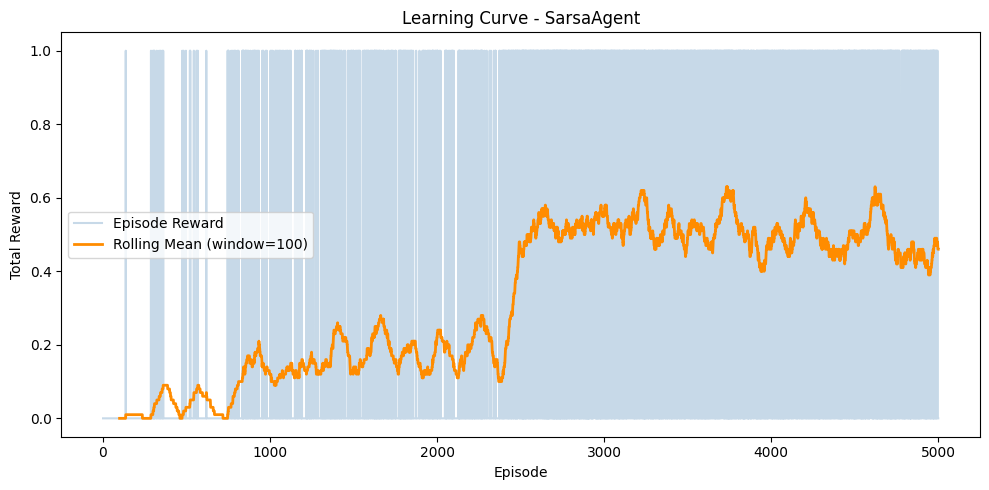

[SarsaAgent] 평가 500 에피소드
  평균 보상 : 0.574
  성공률   : 57.4%


In [16]:
# FrozenLake-v1 환경 생성
# is_slippery=True : 미끄러운 얼음판 (의도한 방향으로 이동 확률 1/3, 기본 설정)
env_fl = gym.make("FrozenLake-v1", is_slippery=True)
adapter_fl = DiscreteEnvironmentAdapter(env_fl)
# 이산 상태 환경 어댑터 생성 (상태 : 0~15 정수)

agent_sarsa = SarsaAgent(
    action_space = env_fl.action_space.n,  # 4 (상/하/좌/우)
    rho          = 0.1,                    # 학습률
    gamma        = 0.99,                   # 할인율
    epsilon      = 1.0,                    # 초기 탐험률 (완전 탐험)
)

trainer_sarsa = AgentTrainer(agent_sarsa, adapter_fl)
result_sarsa  = trainer_sarsa.train(
    episodes      = 5000,
    epsilon_decay = 0.995,           # Є-곱 스케줄링 감소 비율
    epsilon_min   = 0.01,            # 탐험률 하한값
    decay_type    = "multiplicative",
)

trainer_sarsa.plotLearningCurve(result_sarsa["rewards_history"])
eval_sarsa = trainer_sarsa.evaluate(episodes=500)
# 평가 지표 : 성공률 (목표 지점 도달 에피소드 수 / 전체 에피소드 수)
# FrozenLake 보상 구조 : 목표(G) 도달 시 +1, 구멍(H) 빠지거나 시간 초과 시 0
# is_slippery=True 특성상 성공률 낮음 → 하이퍼파라미터 조정 필요


### 5.5.2. FrozenLake 환경에서 QLearning 학습

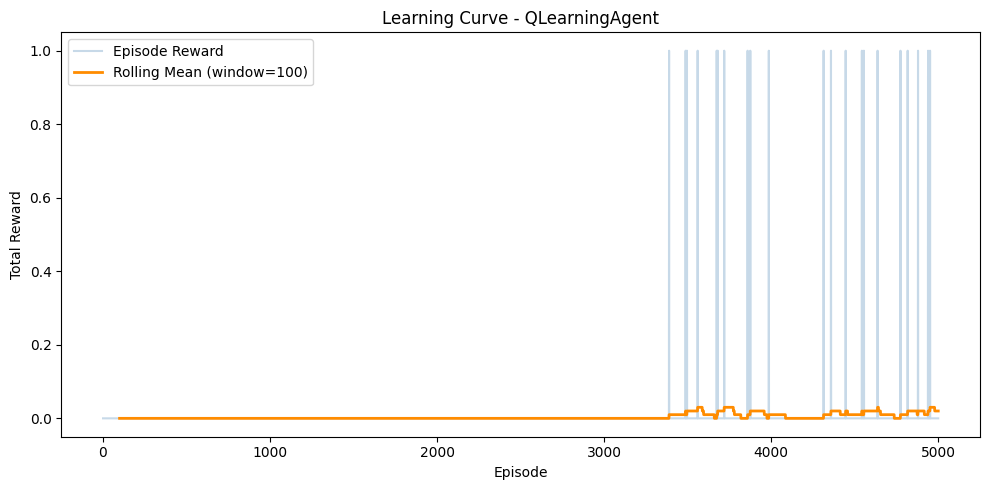

[QLearningAgent] 평가 500 에피소드
  평균 보상 : 0.028
  성공률   : 2.8%


In [17]:
# FrozenLake-v1 환경 재사용 (adapter_fl)
agent_qlearning_fl = QLearningAgent(
    action_space = env_fl.action_space.n,  # 4 (상/하/좌/우)
    rho          = 0.1,                    # 학습률
    gamma        = 0.99,                   # 할인율
    epsilon      = 1.0,                    # 초기 탐험률
)

trainer_qlearning_fl = AgentTrainer(agent_qlearning_fl, adapter_fl)
result_qlearning_fl  = trainer_qlearning_fl.train(
    episodes      = 5000,
    epsilon_decay = 0.995,
    epsilon_min   = 0.01,
    decay_type    = "multiplicative",
)

trainer_qlearning_fl.plotLearningCurve(result_qlearning_fl["rewards_history"])
eval_qlearning_fl = trainer_qlearning_fl.evaluate(episodes=500)
# 평가 지표 : 성공률 (Sarsa 결과와 비교)
# Off-policy Q-Learning vs On-policy Sarsa
# Q-Learning : 최적 행동값 함수로 직접 수렴 → 수렴 빠름, 위험한 경로 선호
# Sarsa      : 현재 정책 기반 학습 → 수렴 느림, 안전한 경로 선호


### 5.6.1. Blackjack 환경에서 QLearning 학습

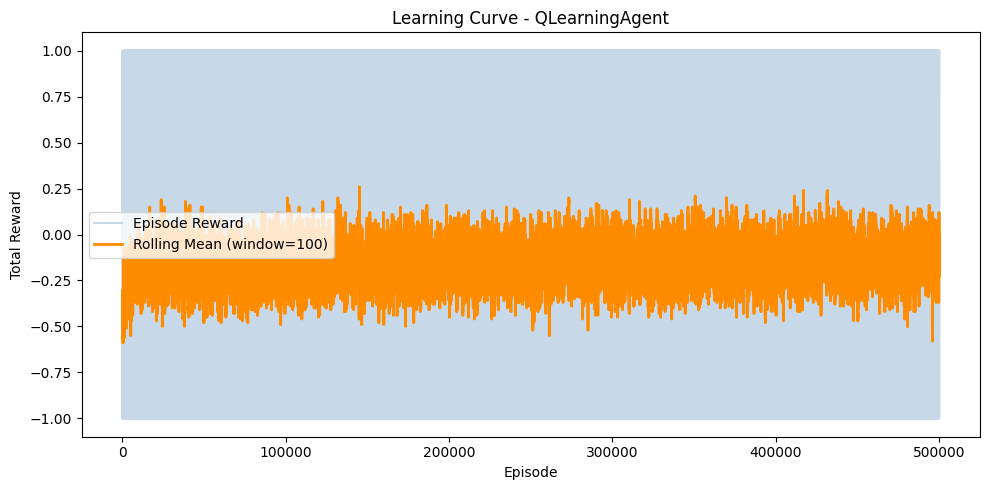

[QLearningAgent] 평가 10000 에피소드
  평균 보상 : -0.085
  성공률   : 42.0%


In [18]:
# Blackjack-v1 환경 생성
# 상태 : (player_sum, dealer_card, usable_ace) - 이산 튜플 → DiscreteEnvironmentAdapter 사용
# 행동 : 0 = stand(멈춤), 1 = hit(카드 추가)
env_bj    = gym.make("Blackjack-v1")
adapter_bj = DiscreteEnvironmentAdapter(env_bj)

agent_qlearning_bj = QLearningAgent(
    action_space = env_bj.action_space.n,  # 2 (stand / hit)
    rho          = 0.05,                   # 학습률 (에피소드가 짧아 낮게 설정)
    gamma        = 1.0,                    # 할인율 (에피소드 내 보상이 끝에만 주어져 할인 없음)
    epsilon      = 1.0,                    # 초기 탐험률
)

trainer_bj = AgentTrainer(agent_qlearning_bj, adapter_bj)
result_bj  = trainer_bj.train(
    episodes      = 500000,   # 상태 공간이 넓으므로 충분한 에피소드 필요
    epsilon_decay = 0.9999,   # 느리게 감소 (탐험을 오래 유지)
    epsilon_min   = 0.05,
    decay_type    = "multiplicative",
)

trainer_bj.plotLearningCurve(result_bj["rewards_history"])
eval_bj = trainer_bj.evaluate(episodes=10000)
# 평가 지표 : 승률 (reward > 0 에피소드 비율)
# Blackjack 보상 구조 : 승 +1 / 무승부 0 / 패 -1
# 최적 블랙잭 전략(Basic Strategy) 기준 승률 약 42~45% 수준


### 5.6.2. CartPole 환경에서 QLearning 학습 (+ 상태 이산화)

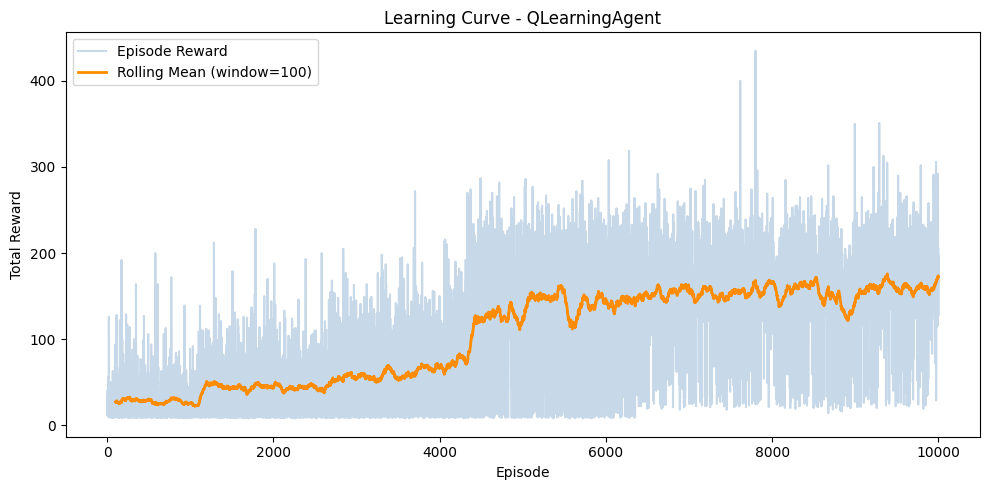

[QLearningAgent] 평가 100 에피소드
  평균 보상 : 177.290
  성공률   : 100.0%


In [19]:
# CartPole-v1 연속 상태 이산화
# 상태 : [카트 위치, 카트 속도, 막대 각도, 막대 각속도] - 4차원 연속 공간
# 5.2.3 셀에서 측정한 상태 범위 기반으로 bin 설정
bins_cp = [
    np.linspace(-4.8,  4.8,  9),  # 카트 위치
    np.linspace(-4.0,  4.0,  9),  # 카트 속도
    np.linspace(-0.42, 0.42, 9),  # 막대 각도
    np.linspace(-4.0,  4.0,  9),  # 막대 각속도
]

env_cp    = gym.make("CartPole-v1")
adapter_cp = ContinuousEnvironmentAdapter(env_cp, bins_cp)
# 연속 상태를 bin 인덱스 튜플로 이산화하는 어댑터

agent_qlearning_cp = QLearningAgent(
    action_space = env_cp.action_space.n,  # 2 (왼쪽 / 오른쪽)
    rho          = 0.1,                    # 학습률
    gamma        = 0.99,                   # 할인율
    epsilon      = 1.0,                    # 초기 탐험률
)

trainer_cp = AgentTrainer(agent_qlearning_cp, adapter_cp)
result_cp  = trainer_cp.train(
    episodes      = 10000,
    epsilon_decay = 0.995,
    epsilon_min   = 0.01,
    decay_type    = "multiplicative",
)

trainer_cp.plotLearningCurve(result_cp["rewards_history"])
eval_cp = trainer_cp.evaluate(episodes=100)
# 평가 지표 : 평균 에피소드 길이 (= 평균 보상, 매 스텝 +1)
# CartPole 보상 구조 : 매 스텝 +1 → 오래 버틸수록 높은 보상
# gymnasium 기준 : 100 에피소드 평균 195 이상이면 solved로 간주
# bin 수·범위 조정으로 이산화 해상도 변경 → 성능 변화 실험 가능
